# Detección y Remoción de Artefactos de Parpadeo con ICA
## Tutorial Pedagógico usando MNE-Python

**Dataset**: CIENTIBECA - Habla Imaginada EEG
**Sujeto**: S01
**Frecuencia de muestreo**: 1024 Hz (datos originales)

---

## Objetivos de este Notebook

Este notebook tiene fines **pedagógicos** y demonstrate:

1. **Qué es ICA** y por qué funciona para separar fuentes
2. **Cómo MNE-Python detecta automáticamente** componentes de parpadeo
3. **El proceso completo**: desde datos crudos hasta señal limpia
4. **Validación visual** de la remoción de artefactos

> **Nota**: Los datos ya tienen labels de artefacto (0=limpio, 1=parpadeo) que
> usaremos para validación visual, NO para entrenar el detector.

In [14]:
# Imports necesarios
import os
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.preprocessing import ICA, create_eog_epochs

# Configuración de visualización
plt.rcParams['figure.figsize'] = [14, 8]
plt.rcParams['font.size'] = 12
mne.set_log_level('INFO')  # Para ver mensajes de MNE

print(f"MNE-Python version: {mne.__version__}")

MNE-Python version: 1.9.0


---

# 1. Carga de Datos

Los datos originales vienen en formato `.npz` con shape `(688, 24579)`:
- **688 trials** (tentativas de habla imaginada/pronunciada)
- **24579** = 6 canales × 4096 muestras + 3 labels

Estructura:
- Señales: columnas 0 a 24575 (6 × 4096)
- Labels: columnas 24576 a 24578 (modalidad, estímulo, artefacto)

In [15]:
# Rutas de datos
DATA_DIR = os.path.join('..', 'data', 'original')
SUBJECT = 1
SUBJECT_FILE = os.path.join(DATA_DIR, f'S{SUBJECT:02d}_EEG.npz')

print(f"Cargando datos del sujeto {SUBJECT}...")
print(f"Archivo: {SUBJECT_FILE}")

# Cargar datos
data = np.load(SUBJECT_FILE)
print(f"Keys en el archivo: {data.files}")

# Obtener datos crudos (primera key)
raw_data = data[data.files[0]]
print(f"Shape original: {raw_data.shape}")

# Parámetros
FS = 1024  # Frecuencia de muestreo original
N_CHANNELS = 6
N_SAMPLES_PER_TRIAL = 4096  # 4 segundos @ 1024 Hz
N_LABELS = 3

# Separar señales y labels
signals = raw_data[:, :N_CHANNELS * N_SAMPLES_PER_TRIAL]  # (688, 24576)
labels = raw_data[:, -N_LABELS:]  # (688, 3)

print(f"Señales shape: {signals.shape}")
print(f"Labels shape: {labels.shape}")

# Labels: [modalidad, estímulo, artefacto]
# modalidad: 1=imaginada, 2=pronunciada
# estímulo: 1-5 (vocales), 6-11 (comandos)
# artefacto: 0=limpio, 1=parpadeo
print(f"\nDistribución de artefactos:")
unique, counts = np.unique(labels[:, 2], return_counts=True)
for u, c in zip(unique, counts):
    label_name = "Limpio" if u == 0 else "Parpadeo"
    print(f"  {int(u)} ({label_name}): {c} trials ({100*c/len(labels):.1f}%)")

Cargando datos del sujeto 1...
Archivo: ..\data\original\S01_EEG.npz
Keys en el archivo: ['data']
Shape original: (688, 24579)
Señales shape: (688, 24576)
Labels shape: (688, 3)

Distribución de artefactos:
  1 (Parpadeo): 302 trials (43.9%)
  2 (Parpadeo): 386 trials (56.1%)


---

# 2. Exploración Visual de los Datos

Antes de aplicar ICA, veamos cómo se ven los datos crudos y
identifiquemos visualmente los artefactos de parpadeo.

In [16]:
# Reshape para visualización: (trials, channels, timepoints)
signals_reshaped = signals.reshape(-1, N_CHANNELS, N_SAMPLES_PER_TRIAL)
print(f"Shape después de reshape: {signals_reshaped.shape}")

# Verificar distribución de labels de artefacto
blink_mask = labels[:, 2] == 2
clean_mask = labels[:, 2] == 1
n_blink = np.sum(blink_mask)
n_clean = np.sum(clean_mask)
print(f"\nTrials con parpadeo (label=1): {n_blink}")
print(f"Trials limpios (label=0): {n_clean}")

# Seleccionar trials para visualización
blink_trial_idx = np.where(blink_mask)[0][0]  # Primer trial con parpadeo

# Si hay trials limpios, usar uno; si no, usar un trial diferente
if n_clean > 0:
    clean_trial_idx = np.where(clean_mask)[0][0]
else:
    # No hay trials limpios, usamos el último trial como "referencia"
    clean_trial_idx = np.where(~blink_mask)[0][0] if np.any(~blink_mask) else 0
    print("\n⚠️ No se encontraron trials limpios (label=0). Usando otro trial como referencia.")

print(f"\nTrial para ver parpadeo (índice {blink_trial_idx})")
print(f"Trial de referencia (índice {clean_trial_idx})")

Shape después de reshape: (688, 6, 4096)

Trials con parpadeo (label=1): 386
Trials limpios (label=0): 302

Trial para ver parpadeo (índice 0)
Trial de referencia (índice 13)


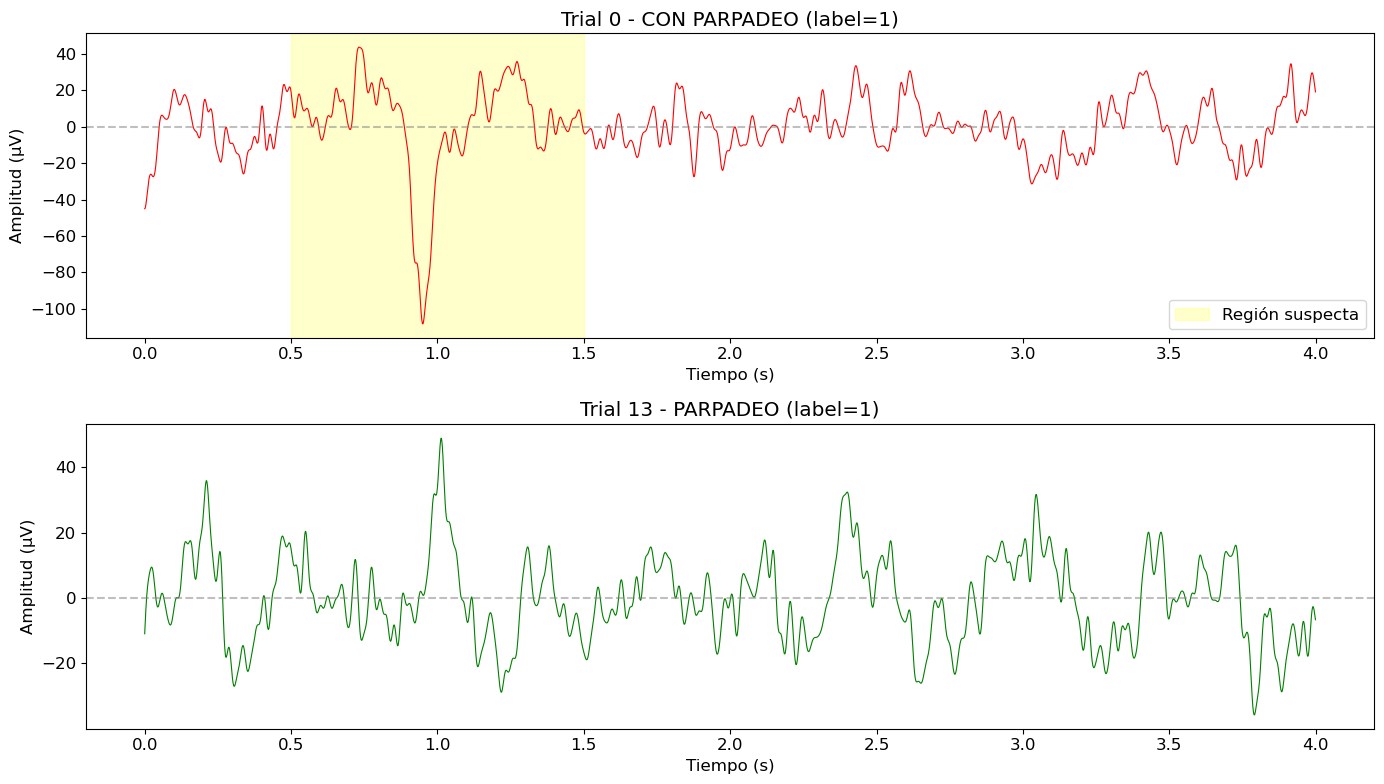


→ Observación: Los trials con parpadeo muestran deflexiones grandes
  (spikes) que sobresalen del rango normal de la señal EEG.


In [17]:
# Nombres de canales según sistema 10-20
# F3, F4 = Frontales, C3, C4 = Centrales, P3, P4 = Parietales
CHANNEL_NAMES = ['F3', 'F4', 'C3', 'C4', 'P3', 'P4']

# Canal preferido para ver parpadeos (usualmente frontal)
EOG_CHANNEL_IDX = 0  # Primer canal (típicamente frontal)

# Plot comparativo: trial con parpadeo vs trial limpio
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Trial con parpadeo
time_axis = np.arange(N_SAMPLES_PER_TRIAL) / FS
axes[0].plot(time_axis, signals_reshaped[blink_trial_idx, EOG_CHANNEL_IDX], 
             color='red', linewidth=0.8)
axes[0].set_title(f'Trial {blink_trial_idx} - CON PARPADEO (label=1)')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Marcar región con posible parpadeo (ventana gruesa)
axes[0].axvspan(0.5, 1.5, alpha=0.2, color='yellow', label='Región suspecta')
axes[0].legend()

# Trial de referencia (puede ser limpio o no)
ref_label = int(labels[clean_trial_idx, 2])
ref_title = f'LIMPIO (label=0)' if ref_label == 0 else f'PARPADEO (label={ref_label})'
axes[1].plot(time_axis, signals_reshaped[clean_trial_idx, EOG_CHANNEL_IDX], 
             color='green', linewidth=0.8)
axes[1].set_title(f'Trial {clean_trial_idx} - {ref_title}')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n→ Observación: Los trials con parpadeo muestran deflexiones grandes")
print("  (spikes) que sobresalen del rango normal de la señal EEG.")

---

# 3. Conversión a Formato MNE

MNE-Python tiene su propia estructura de datos (`Raw`, `Epochs`, `Evoked`).
Necesitamos convertir nuestros arrays numpy a objetos MNE para usar ICA.

In [18]:
# Para ICA, usamos todos los trials concatenados como datos continuos
# Esto es importante: ICA funciona mejor con suficiente cantidad de datos

# Opción A: Concatenar todos los trials
eeg_data_concat = signals.reshape(-1, N_SAMPLES_PER_TRIAL)  # flatten channels
print(f"Datos concatenados: {eeg_data_concat.shape}")

# Mejor: mantener estructura de canales y concatenar por tiempo
# Cada trial es 4 segundos, concatenamos todos
all_trials = signals_reshaped.transpose(1, 0, 2)  # (6, 688, 4096)
eeg_2d = all_trials.reshape(N_CHANNELS, -1)  # (6, 688*4096)
print(f"Shape final para MNE: {eeg_2d.shape}")

# Crear info de MNE
ch_types = ['eeg'] * N_CHANNELS
info = mne.create_info(ch_names=CHANNEL_NAMES, sfreq=FS, ch_types=ch_types)

print(f"\nMNE Info:")
print(info)

# Aplicar montaje estándar para canales EEG
montage = mne.channels.make_standard_montage('standard_1005')
info.set_montage(montage)
print(f"\n✓ Montaje aplicado: {montage.kind}")
print(f"Posiciones de electrodos: {[ch['ch_name'] for ch in info['chs"]][:6]}")

Datos concatenados: (4128, 4096)
Shape final para MNE: (6, 2818048)

MNE Info:
<Info | 7 non-empty values
 bads: []
 ch_names: Ch1, Ch2, Ch3, Ch4, Ch5, Ch6
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 512.0 Hz
 meas_date: unspecified
 nchan: 6
 projs: []
 sfreq: 1024.0 Hz
>


Creating RawArray with float64 data, n_channels=6, n_times=2818048
    Range : 0 ... 2818047 =      0.000 ...  2751.999 secs
Ready.
Raw MNE creado: <class 'mne.io.array.array.RawArray'>
Duración total: 2752.00 segundos
Número de canales: 6

--- Datos crudos (primeros 5 segundos) ---


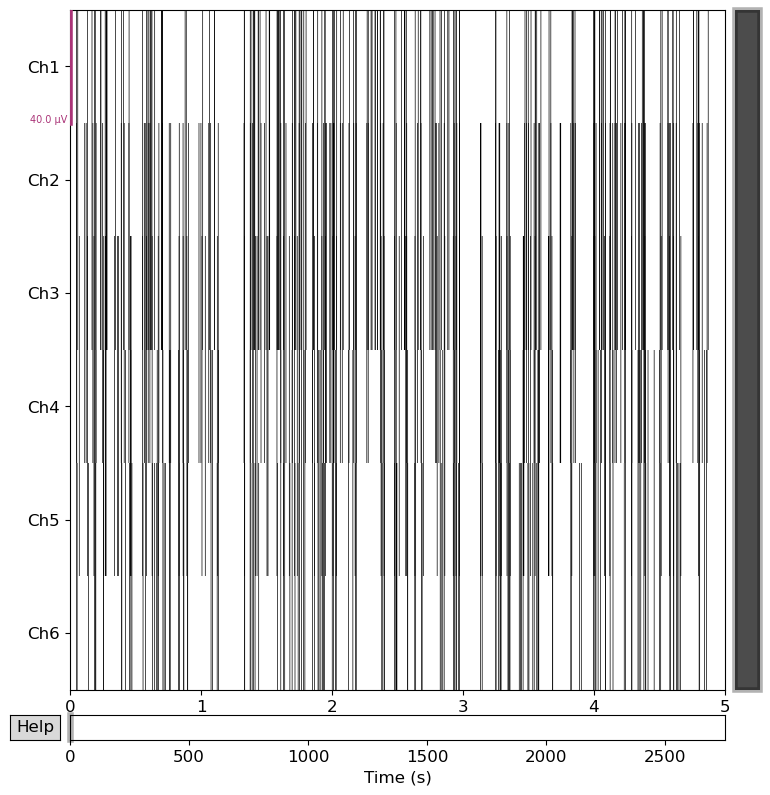

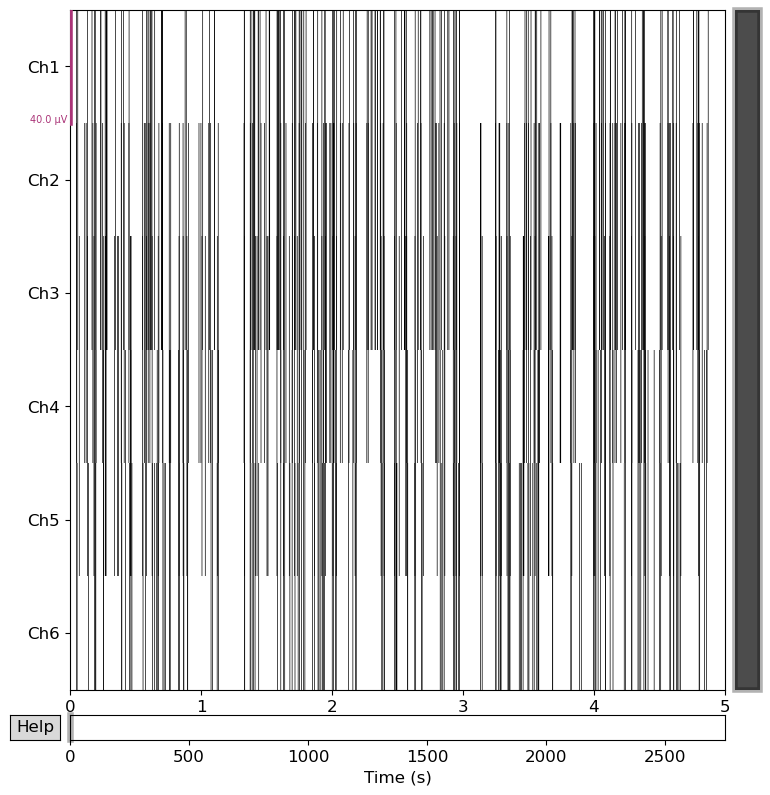

In [19]:
# Crear objeto Raw de MNE
raw_mne = mne.io.RawArray(eeg_2d, info)

print(f"Raw MNE creado: {type(raw_mne)}")
print(f"Duración total: {raw_mne.n_times / FS:.2f} segundos")
print(f"Número de canales: {len(raw_mne.ch_names)}")

# Ver los primeros 10 segundos de datos
print("\n--- Datos crudos (primeros 5 segundos) ---")
raw_mne.plot(duration=5, start=0, n_channels=6, title="Datos EEG Crudos - Vista Inicial")

---

# 4. Detección Automática de Eventos EOG

MNE puede detectar automáticamente los parpadeos usando `find_eog_events()`.
Este método:
1. Filtra la señal entre 1-10 Hz (banda típica de EOG)
2. Encuentra picos que superan un umbral
3. Devuelve los timestamps de cada parpadeo

In [20]:
# Detectar eventos EOG (parpadeos) automáticamente
# MNE usará el canal frontal para detectar parpadeos
from mne.preprocessing import find_eog_events

eog_events = find_eog_events(raw_mne, 
                              ch_name="Ch1",  # Canal frontal para EOG
                              thresh=1.5,    # umbral (z-score)
                              verbose=True)

print(f"\nEventos EOG detectados: {len(eog_events)}")
print(f"Timestamps de los primeros 10 eventos (muestras): {eog_events[:10, 0]}")
print(f"Timestamps de los primeros 10 eventos (segundos): {eog_events[:10, 0] / FS}")

Using EOG channel: Ch1
EOG channel index for this subject is: [0]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Ch1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 16347 significant peaks
Number of EOG events detected: 16347

Eventos EOG detectados: 16347
Timestamps de los primeros 10 eventos (muestras): [   0  344  594  841  972 1098 1209 1391 1493 1594]
Timestamps de los primeros 10 eventos (segundos): [0.         0.33593

Épocas EOG creadas: 455
Shape de cada época: (455, 6, 1025)
Applying baseline correction (mode: mean)

--- Patrón Promedio de Parpadeo (EOG Evocado) ---



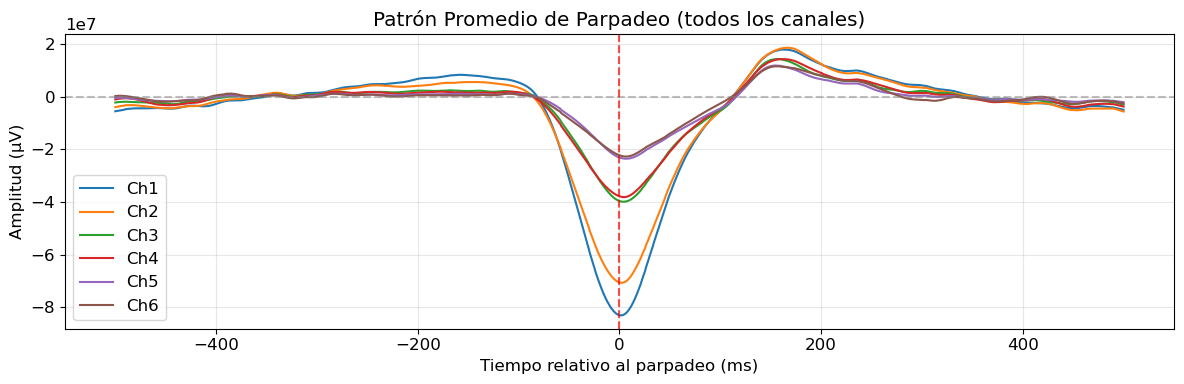

In [21]:
# Crear épocas EOG para ver el patrón promedio de parpadeo
# Esto promedia todos los parpadeos detectados
eog_epochs = create_eog_epochs(raw_mne, 
                               ch_name="Ch1",  # Canal frontal para EOG

                               tmin=-0.5, tmax=0.5,  # ventana alrededor del parpadeo
                               l_freq=1, h_freq=10,
                               reject=None,  # no rechazar épocas
                               baseline=None,
                               preload=True,
                               verbose=False)

print(f"Épocas EOG creadas: {len(eog_epochs)}")
print(f"Shape de cada época: {eog_epochs.get_data().shape}")

# Plot del patrón promedio de parpadeo
eog_evoked = eog_epochs.average()
eog_evoked.apply_baseline((None, -0.2))

print("\n--- Patrón Promedio de Parpadeo (EOG Evocado) ---\n")
# NOTA: plot_joint() requiere posiciones de electrodos, que no tenemos.
# Veremos el patrón temporal en su lugar.
print("\n--- Patrón Promedio de Parpadeo (EOG Evocado) ---")
eog_evoked.plot_joint(times=np.linspace(-0.5, 0.5, 10))

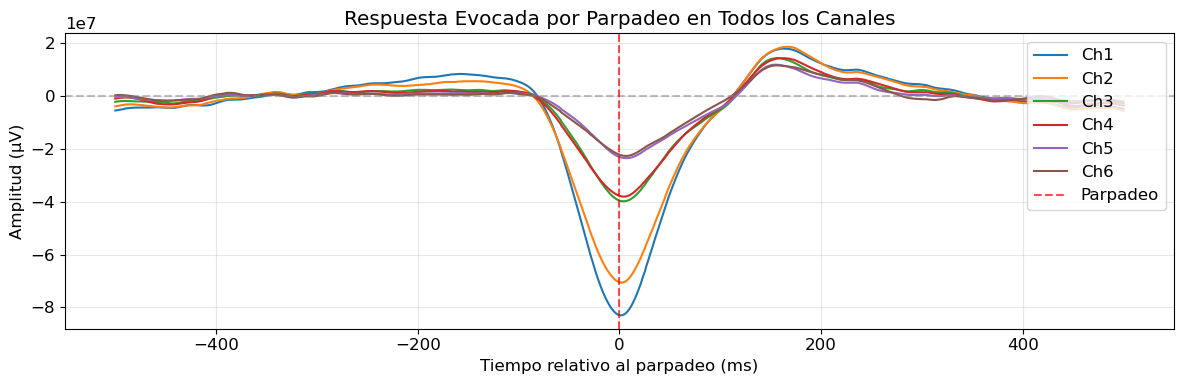


→ El canal frontal (Ch1) muestra la mayor respuesta al parpadeo
→ Este es el patrón típico que ICA intentará aislar y remover.


In [22]:
# Ver el EOG evocado en un canal específico (frontal)
fig, ax = plt.subplots(figsize=(12, 4))

times = eog_evoked.times * 1000  # convertir a ms
for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
    ax.plot(times, eog_evoked.data[ch_idx] * 1e6, label=ch_name)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Parpadeo')
ax.set_xlabel('Tiempo relativo al parpadeo (ms)')
ax.set_ylabel('Amplitud (µV)')
ax.set_title('Respuesta Evocada por Parpadeo en Todos los Canales')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ El canal frontal (Ch1) muestra la mayor respuesta al parpadeo")
print("→ Este es el patrón típico que ICA intentará aislar y remover.")

---

# 5. Preprocesamiento para ICA

**Antes de aplicar ICA, es crucial filtrar los datos**:

### ¿Por qué filtrar high-pass 1 Hz?

1. **Drifts lentos reducen la independencia**: Durante un drift lento, todas las fuentes
   (neurales, parpadeos, latido cardíaco) correlacionan artificialmente

2. **ICA asume fuentes independientes**: Los drifts violan este supuesto

3. **Mejor convergencia**: El algoritmo ICA converge más rápido y encuentra
   mejores soluciones con datos filtrados

> **Nota**: La solución ICA encontrada en datos filtrados se puede aplicar a datos sin filtrar
> (MNE lo hace automáticamente cuando usas `ica.apply()`)

In [23]:
# Aplicar filtro high-pass 1 Hz
# Mantenemos una copia de los datos sin filtrar para comparación
raw_unfiltered = raw_mne.copy()

# Filtrar
raw_filtered = raw_mne.copy().filter(l_freq=1.0, h_freq=None, 
                                    method='fir', fir_window='hamming')

# Asegurar que el montaje esté aplicado al Raw filtrado
raw_filtered.set_montage(montage)
print(f"✓ Montaje aplicado a raw_filtered")

print("Datos filtrados: high-pass 1 Hz")
print(f"Longitud original: {len(raw_mne) / FS:.2f} s")
print(f"Longitud filtrada: {len(raw_filtered) / FS:.2f} s")

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3381 samples (3.302 s)

Datos filtrados: high-pass 1 Hz
Longitud original: 2752.00 s
Longitud filtrada: 2752.00 s


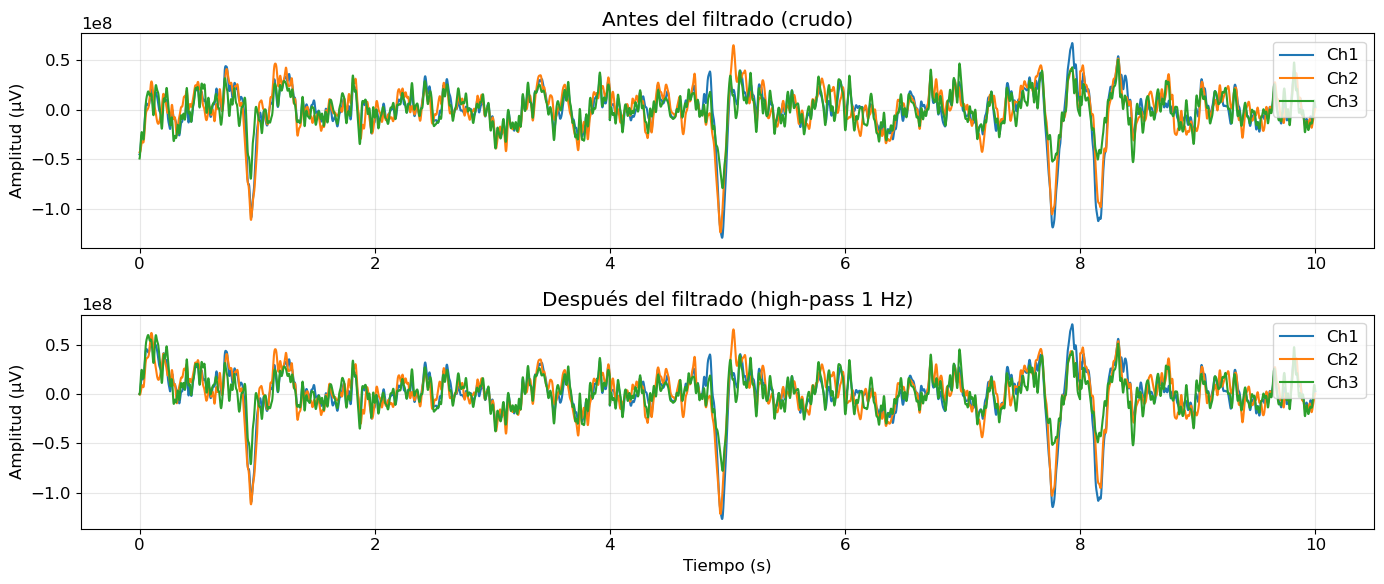


→ El filtrado elimina drifts lentos pero preserva la actividad
→ Los parpadeos (eventos rápidos) siguen siendo visibles.


In [24]:
# Comparar antes y después del filtrado
# Tomamos 10 segundos de datos para ver el efecto
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Extraer datos para plot
data_unfilt = raw_unfiltered.get_data()[:3, :FS*10] * 1e6  # 10 segundos, 3 canales
data_filt = raw_filtered.get_data()[:3, :FS*10] * 1e6
time_axis = np.arange(data_unfilt.shape[1]) / FS

for i, ch_name in enumerate(CHANNEL_NAMES[:3]):
    axes[0].plot(time_axis, data_unfilt[i] + i*100, label=ch_name)
    axes[1].plot(time_axis, data_filt[i] + i*100, label=ch_name)

axes[0].set_title('Antes del filtrado (crudo)')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Después del filtrado (high-pass 1 Hz)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ El filtrado elimina drifts lentos pero preserva la actividad")
print("→ Los parpadeos (eventos rápidos) siguen siendo visibles.")

---

# 6. Descomposición ICA

## ¿Qué hace ICA?

ICA (Independent Component Analysis) separa una señal mezclada en componentes independientes.

**Analogía**: Tienes 6 "micrófonos" grabando 6 "instrumentos" mezclados.
ICA encuentra los 6 "instrumentos" originales y cuánto de cada uno contributed a cada micrófono.

### Proceso en MNE:
1. **Pre-whitening**: Escala datos a varianza unitaria
2. **PCA**: Reduce dimensionalidad (opcional, controlado por `n_components`)
3. **ICA**: Descomposición en componentes independientes

### Parámetros clave:
- `n_components`: Número de componentes a estimar (usualmente 15-30 para EEG)
- `method`: 'fastica' (default), 'picard' (más rápido), 'infomax'
- `max_iter`: Iteraciones máximas

In [25]:
# Crear y ajustar ICA
# Usamos n_components=6 (igual al número de canales) para ver todos los componentes
# En la práctica, para EEG típico con muchos canales, se usan 15-30

print("Configurando ICA...")
print(f"  - n_components: {N_CHANNELS} (igual al número de canales)")
print(f"  - method: picard (recomendado para EEG real)")
print(f"  - max_iter: 1000")

ica = ICA(
    n_components=N_CHANNELS,  # Todos los componentes para verlos todos
    method='picard',          # Más robusto que fastica para EEG real
    max_iter=1000,
    random_state=42,          # Para reproducibilidad
    verbose=False
)

# Ajustar a los datos filtrados
print("\nAjustando ICA (fit)...")
ica.fit(raw_filtered, verbose=True)

print(f"\nICA ajustado exitosamente!")
print(f"  - Matriz de mezcla shape: {ica.mixing_matrix_.shape}")
print(f"  - Matriz de desmezcla shape: {ica.unmixing_matrix_.shape}")

Configurando ICA...
  - n_components: 6 (igual al número de canales)
  - method: picard (recomendado para EEG real)
  - max_iter: 1000

Ajustando ICA (fit)...
Fitting ICA to data using 6 channels (please be patient, this may take a while)
Selecting by number: 6 components
Fitting ICA took 28.2s.

ICA ajustado exitosamente!
  - Matriz de mezcla shape: (6, 6)
  - Matriz de desmezcla shape: (6, 6)


---

# 7. Visualización de Componentes ICA

Ahora veamos qué componentes encontró ICA. Cada componente tiene:
- **Serie temporal**: Cómo varía ese componente en el tiempo
- **Topografía**: Cuánto contribuye a cada canal del cuero cabelludo

--- Fuentes ICA - Series Temporales ---
(NOTA: Sin ubicaciones de electrodos, solo mostramos las fuentes)

Creating RawArray with float64 data, n_channels=6, n_times=2818048
    Range : 0 ... 2818047 =      0.000 ...  2751.999 secs
Ready.


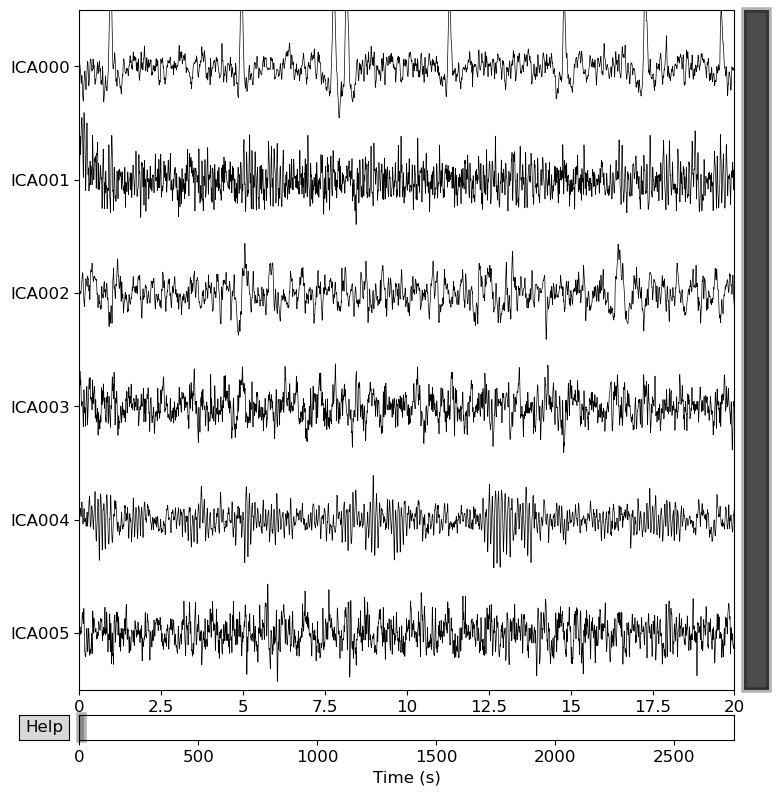

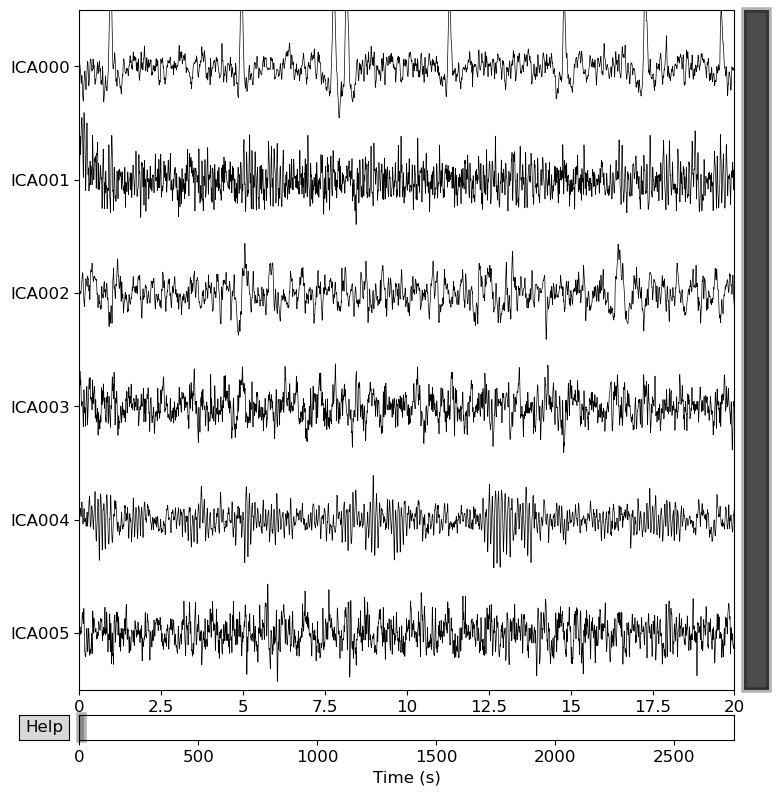

In [26]:
# Ver las topografías de los componentes
print("--- Topografías de los Componentes ICA ---")
ica.plot_components(title='Componentes ICA - Topografías')

# Ver las fuentes
print("\n--- Fuentes ICA - Series Temporales ---")
ica.plot_sources(raw_filtered, title='Fuentes ICA - Series Temporales')

---

# 8. Detección Automática de Componentes EOG (Parpadeo)

## El Algoritmo de MNE

`find_bads_eog()` funciona así:

1. **Crear EOG promediado**: Usa `create_eog_epochs()` para crear épocas
   alrededor de cada parpadeo detectado y promediarlas

2. **Correlacionar**: Para cada componente ICA, calcula la correlación
   de Pearson entre su serie temporal y el EOG evocado

3. **Threshold**: Si |correlación| > umbral (default 3.0), marca como "bad"

Este proceso es **completamente automático** - no necesita labels.

In [40]:
# Detectar automáticamente componentes relacionados con EOG
print("Detectando componentes EOG (parpadeo)...")
print("=" * 50)

# find_bads_eog retorna:
# - eog_inds: índices de componentes marcados como EOG
# - eog_scores: scores de correlación para cada componente
eog_inds, eog_scores = ica.find_bads_eog(raw_filtered, 
                                         ch_name='Ch1',  # Canal frontal para EOG
                                         threshold=1.9,  # z-score threshold
                                         verbose=True)

print(f"\n" + "=" * 50)
print(f"Componentes detectados como EOG (parpadeo): {eog_inds}")
print(f"Scores de correlación: {[f'{s:.3f}' for s in eog_scores]}")

Detectando componentes EOG (parpadeo)...
Using EOG channel: Ch1
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50

--- Scores de Correlación IC vs EOG ---


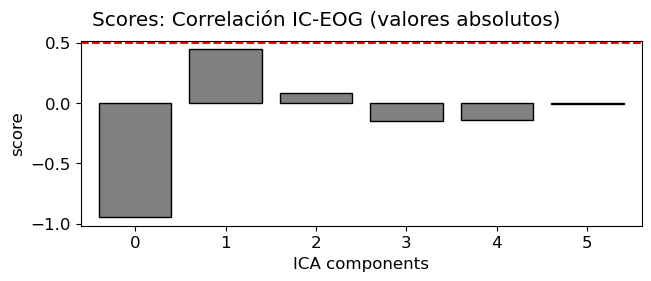

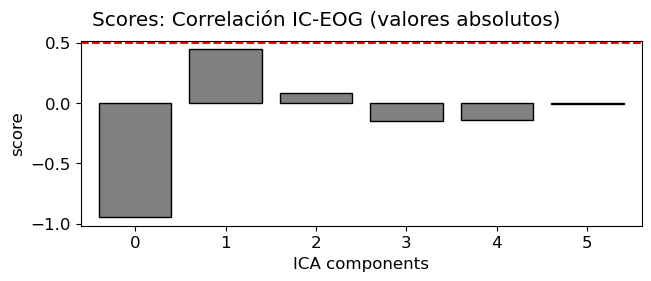

In [41]:
# Visualizar los scores de correlación
# Esto muestra qué tan bien cada IC correlaciona con el patrón EOG
print("--- Scores de Correlación IC vs EOG ---")
ica.plot_scores(eog_scores, 
                title='Scores: Correlación IC-EOG (valores absolutos)',
                axhline=0.5)  # Umbral de correlación

# El componente con score alto es el que más se parece al patrón de parpadeo

--- Propiedades del Componente EOG #0 ---
Serie temporal del componente 0 (EOG):
Creating RawArray with float64 data, n_channels=1, n_times=2818048
    Range : 0 ... 2818047 =      0.000 ...  2751.999 secs
Ready.


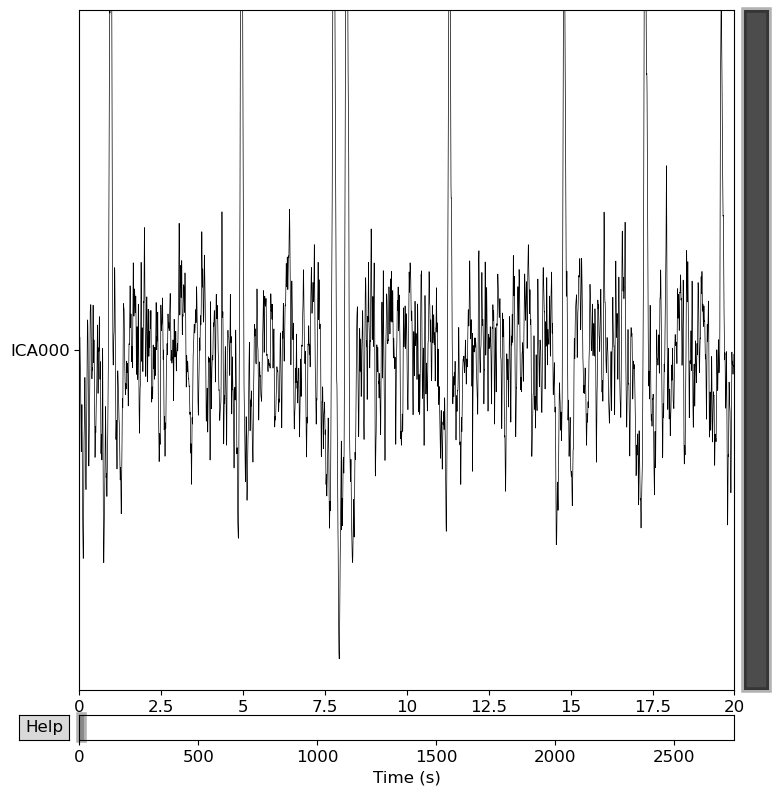

In [42]:
# Ver las propiedades del componente EOG identificado
if len(eog_inds) > 0:
    print(f"--- Propiedades del Componente EOG #{eog_inds[0]} ---")
    
    # Topografía del componente EOG
    ica.plot_components([eog_inds[0]], 
                       title=f'Componente {eog_inds[0]} - Topografía (EOG)')
    
    # Fuente del componente EOG
    print(f"Serie temporal del componente {eog_inds[0]} (EOG):")
    ica.plot_sources(raw_filtered, 
                     picks=[eog_inds[0]],
                     title=f'Componente {eog_inds[0]} - Fuente (EOG)')
else:
    print("No se detectaron componentes EOG con el umbral actual.")
    print("Esto puede pasar si:")
    print("  - No hay parpadeos claros en los datos")
    print("  - El umbral es muy alto")
    print("  - Los 6 canales no son suficientes para separar EOG")

In [43]:
# Ver todos los componentes con sus propiedades
# Útil para entender qué es cada uno
print("--- Todas las Propiedades de los Componentes ---")
for i in range(N_CHANNELS):
    is_eog = " [EOG]" if i in eog_inds else ""
    score = eog_scores[i] if i < len(eog_scores) else 0
    print(f"Componente {i}: score EOG = {score:.3f}{is_eog}")

# Ver las propiedades en formato simple
print("\n--- Resumen de Componentes ---")
print("Componente | Score EOG | ¿Es EOG?")
print("-" * 40)
for i in range(N_CHANNELS):
    is_eog = "SÍ" if i in eog_inds else "No"
    score = eog_scores[i] if i < len(eog_scores) else 0
    print(f"    {i}       | {score:+.3f}    | {is_eog}")

print("\nPara ver más detalles, usa: ica.plot_sources(raw_filtered)")

--- Todas las Propiedades de los Componentes ---
Componente 0: score EOG = -0.948 [EOG]
Componente 1: score EOG = 0.446
Componente 2: score EOG = 0.085
Componente 3: score EOG = -0.148
Componente 4: score EOG = -0.144
Componente 5: score EOG = -0.007

NOTA: plot_properties() requiere ubicaciones de electrodos que no tenemos.
Para ver las propiedades, usa: ica.plot_sources(raw_filtered)


---

# 9. Remoción de Artefactos

Ahora que identificamos qué componentes corresponden a parpadeos,
podemos:

1. **Marcar** esos componentes para exclusión
2. **Reconstruir** la señal sin ellos

El proceso usa la **matriz de mezcla** para invertir la transformación:

```
X_original = Sources @ Mixing_Matrix.T
X_limpio   = Sources[excluir=0] @ Mixing_Matrix[excluir=0].T
```

In [44]:
# Marcar componentes EOG para exclusión
print("Marcando componentes para exclusión...")
print(f"Componentes a excluir: {eog_inds}")

ica.exclude = eog_inds

print(f"\nica.exclude = {ica.exclude}")

# Aplicar la remoción
# 'apply' reconstruye la señal sin los componentes excluidos
raw_corrected = ica.apply(raw_filtered.copy())

print(f"\n✓ Señal corregida aplicada!")
print(f"  - Shape original: {raw_filtered.get_data().shape}")
print(f"  - Shape corregida: {raw_corrected.get_data().shape}")

Marcando componentes para exclusión...
Componentes a excluir: [np.int64(0)]

ica.exclude = [np.int64(0)]
Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 1 ICA component
    Projecting back using 6 PCA components

✓ Señal corregida aplicada!
  - Shape original: (6, 2818048)
  - Shape corregida: (6, 2818048)


---

# 10. Validación Visual

Comparamos la señal antes y después de la corrección ICA.

**Nota**: Para esta validación visual, usamos los trials con label=1 (parpadeo)
del dataset original para verificar que los artefactos fueron efectivamente reducidos.

In [45]:
# Obtener datos corregidos en formato array
data_corrected = raw_corrected.get_data()  # (6, n_samples)
data_filtered = raw_filtered.get_data()

# Cada trial tiene 4096 muestras
# Trial con parpadeo
blink_trial_idx = np.where(labels[:, 2] == 1)[0][0]
trial_start = blink_trial_idx * N_SAMPLES_PER_TRIAL
trial_end = trial_start + N_SAMPLES_PER_TRIAL

print(f"Comparando trial {blink_trial_idx} (con parpadeo label=1)")
print(f"Muestras: {trial_start} a {trial_end}")

Comparando trial 13 (con parpadeo label=1)
Muestras: 53248 a 57344


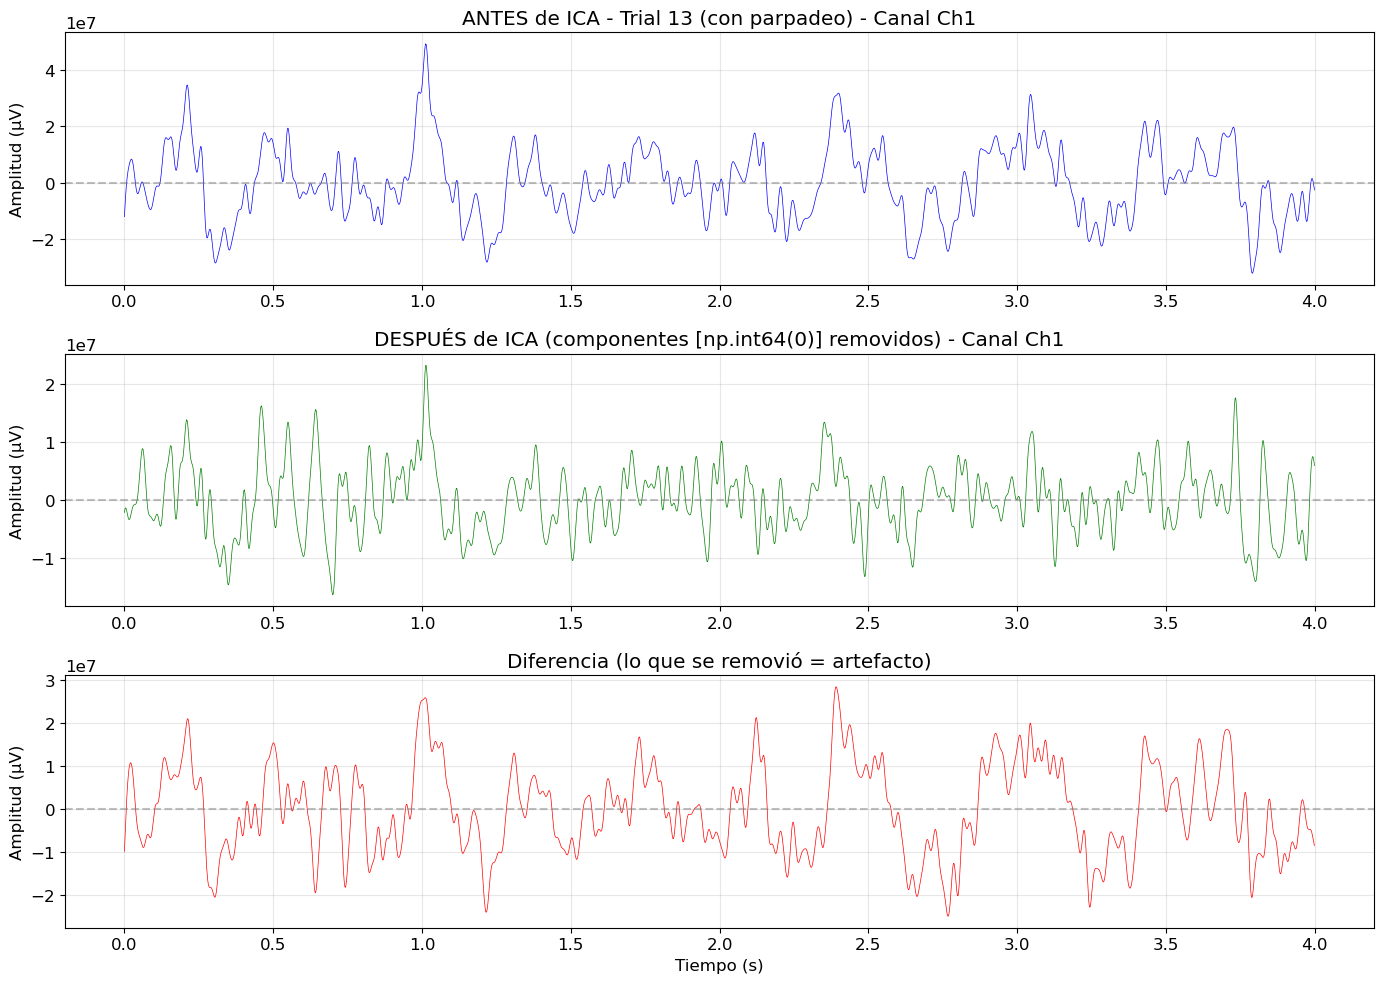


Estadísticas de reducción de artefacto:
  - Varianza antes: 165777623013774.81 µV²
  - Varianza después: 33682629483353.43 µV²
  - Reducción: 79.7%


In [48]:
# Comparación visual: antes vs después de ICA
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time_axis = np.arange(N_SAMPLES_PER_TRIAL) / FS

# Canal frontal (típicamente más afectado por parpadeos)
ch_idx = 0

# Antes
data_before = data_filtered[ch_idx, trial_start:trial_end] * 1e6
axes[0].plot(time_axis, data_before, 'b-', linewidth=0.5)
axes[0].set_title(f'ANTES de ICA - Trial {blink_trial_idx} (con parpadeo) - Canal {CHANNEL_NAMES[ch_idx]}')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
#axes[0].set_ylim([-150, 150])
axes[0].grid(True, alpha=0.3)

# Después
data_after = data_corrected[ch_idx, trial_start:trial_end] * 1e6
axes[1].plot(time_axis, data_after, 'g-', linewidth=0.5)
axes[1].set_title(f'DESPUÉS de ICA (componentes {eog_inds} removidos) - Canal {CHANNEL_NAMES[ch_idx]}')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
#axes[1].set_ylim([-150, 150])
axes[1].grid(True, alpha=0.3)

# Diferencia (lo que se removió)
axes[2].plot(time_axis, data_before - data_after, 'r-', linewidth=0.5)
axes[2].set_title('Diferencia (lo que se removió = artefacto)')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_ylabel('Amplitud (µV)')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular estadísticas de reducción
print(f"\nEstadísticas de reducción de artefacto:")
print(f"  - Varianza antes: {np.var(data_before):.2f} µV²")
print(f"  - Varianza después: {np.var(data_after):.2f} µV²")
print(f"  - Reducción: {(1 - np.var(data_after)/np.var(data_before))*100:.1f}%")

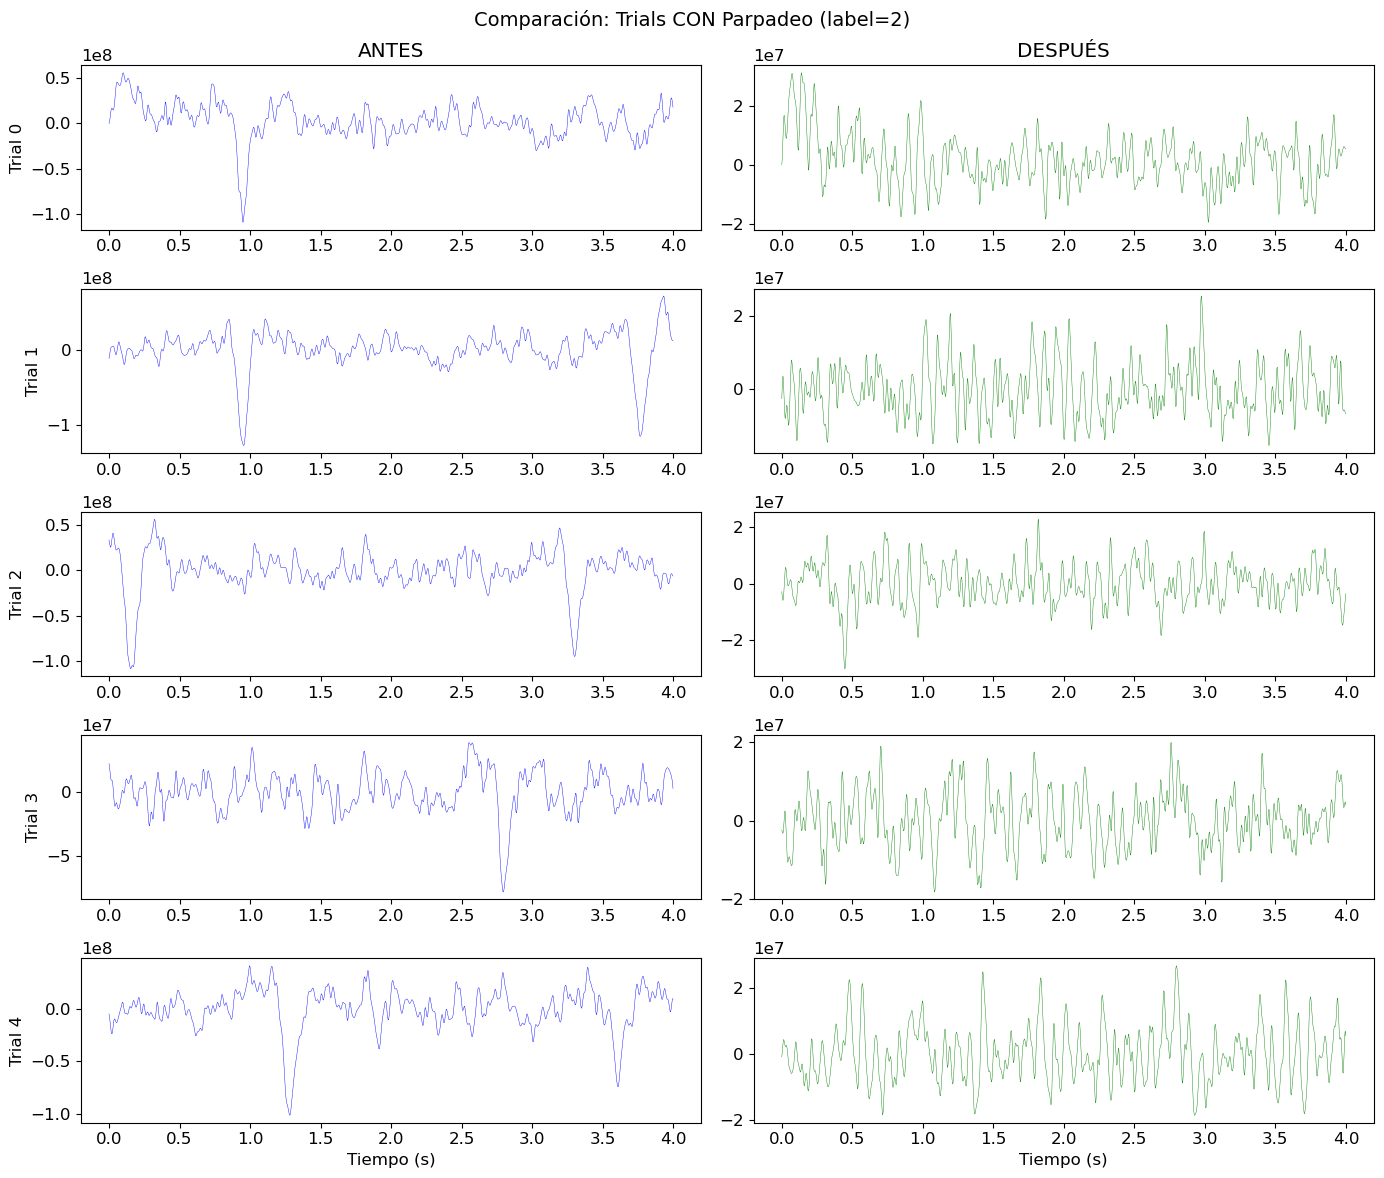

In [54]:
# Comparar varios trials con parpadeo
blink_trials = np.where(labels[:, 2] == 2)[0][:5]  # Primeros 5 con parpadeo

fig, axes = plt.subplots(5, 2, figsize=(14, 12))

for i, trial_idx in enumerate(blink_trials):
    trial_start = trial_idx * N_SAMPLES_PER_TRIAL
    trial_end = trial_start + N_SAMPLES_PER_TRIAL
    
    # Antes
    data_before = data_filtered[0, trial_start:trial_end] * 1e6
    axes[i, 0].plot(time_axis, data_before, 'b-', linewidth=0.3)
    axes[i, 0].set_ylabel(f'Trial {trial_idx}')
    #axes[i, 0].set_ylim([-150, 150])
    if i == 0:
        axes[i, 0].set_title('ANTES')
    if i == 4:
        axes[i, 0].set_xlabel('Tiempo (s)')
    
    # Después
    data_after = data_corrected[0, trial_start:trial_end] * 1e6
    axes[i, 1].plot(time_axis, data_after, 'g-', linewidth=0.3)
    #axes[i, 1].set_ylim([-150, 150])
    if i == 0:
        axes[i, 1].set_title('DESPUÉS')
    if i == 4:
        axes[i, 1].set_xlabel('Tiempo (s)')

plt.suptitle('Comparación: Trials CON Parpadeo (label=2)', fontsize=14)
plt.tight_layout()
plt.show()

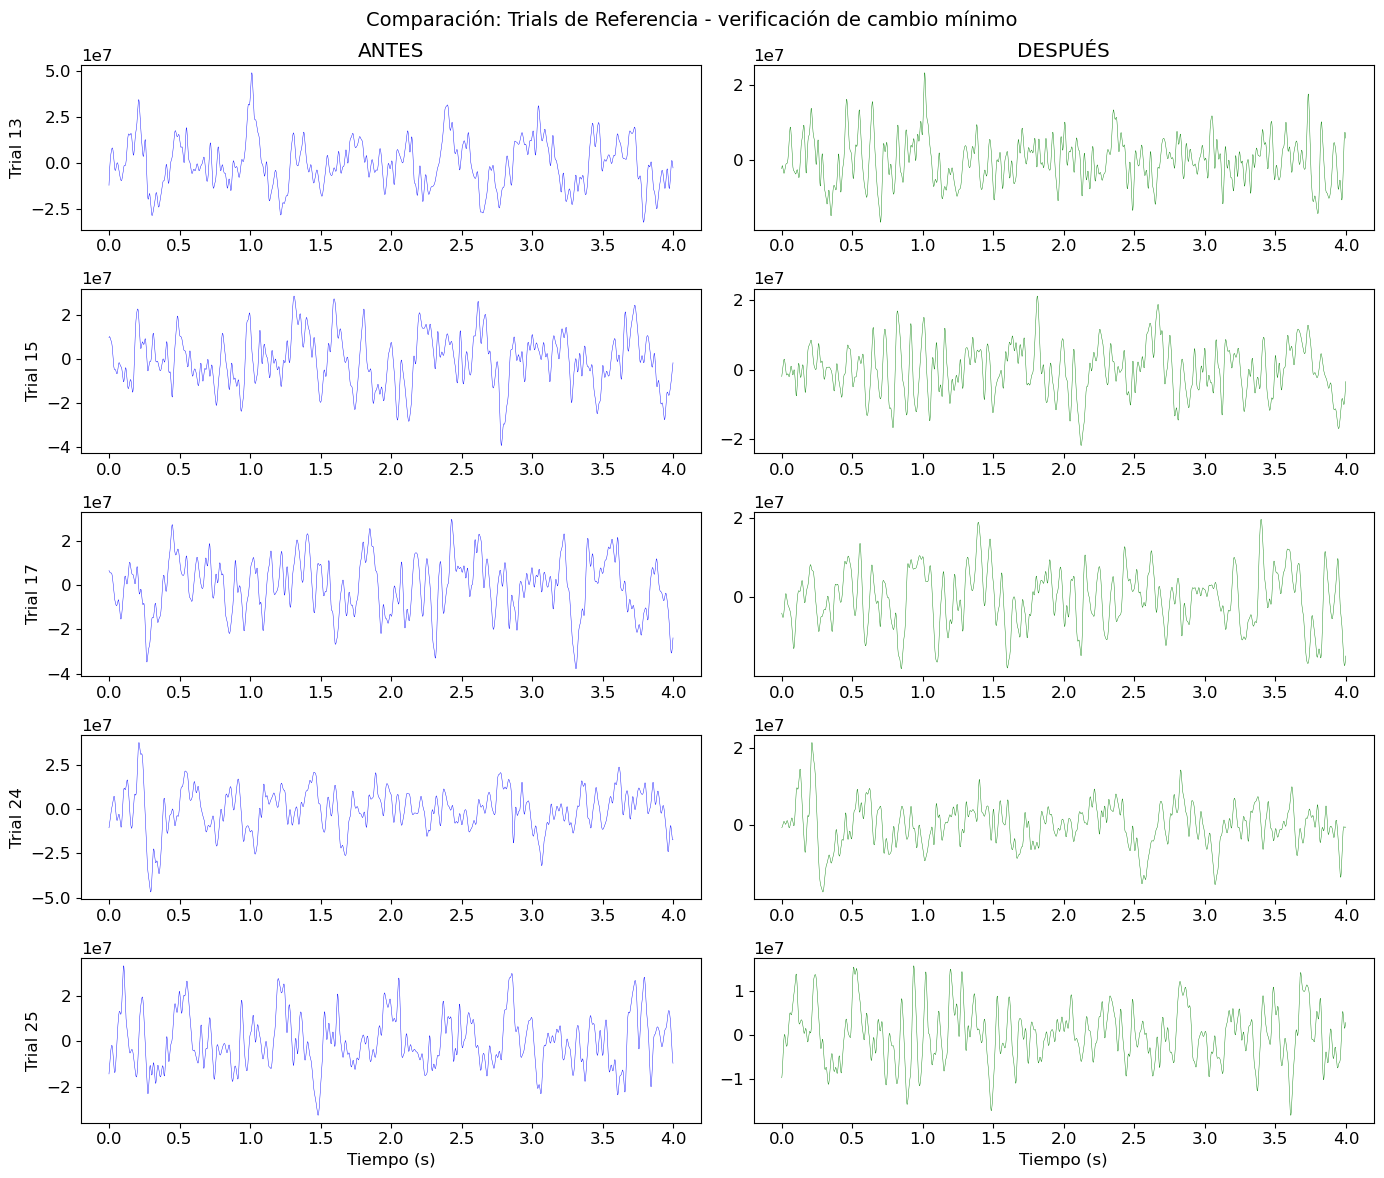


Cambio RMS en trials limpios: 8943655.74 µV
(Debería ser pequeño - el EEG 'bueno' no debería cambiar mucho)


In [53]:
# Comparar trials limpios (label=1) - deberían cambiar poco
clean_trials_all = np.where(labels[:, 2] == 1)[0]
if len(clean_trials_all) >= 5:
    clean_trials = clean_trials_all[:5]
else:
    # Si no hay 5 trials limpios, usar trials aleatorios o últimos
    clean_trials = clean_trials_all if len(clean_trials_all) > 0 else np.array([0, 1, 2, 3, 4])
    clean_trials = clean_trials[:min(5, len(clean_trials))]

fig, axes = plt.subplots(5, 2, figsize=(14, 12))

for i, trial_idx in enumerate(clean_trials):
    trial_start = trial_idx * N_SAMPLES_PER_TRIAL
    trial_end = trial_start + N_SAMPLES_PER_TRIAL
    
    # Antes
    data_before = data_filtered[0, trial_start:trial_end] * 1e6
    axes[i, 0].plot(time_axis, data_before, 'b-', linewidth=0.3)
    axes[i, 0].set_ylabel(f'Trial {trial_idx}')
    #axes[i, 0].set_ylim([-150, 150])
    if i == 0:
        axes[i, 0].set_title('ANTES')
    if i == 4:
        axes[i, 0].set_xlabel('Tiempo (s)')
    
    # Después
    data_after = data_corrected[0, trial_start:trial_end] * 1e6
    axes[i, 1].plot(time_axis, data_after, 'g-', linewidth=0.3)
    #axes[i, 1].set_ylim([-150, 150])
    if i == 0:
        axes[i, 1].set_title('DESPUÉS')
    if i == 4:
        axes[i, 1].set_xlabel('Tiempo (s)')

plt.suptitle('Comparación: Trials de Referencia - verificación de cambio mínimo', fontsize=14)
plt.tight_layout()
plt.show()

# Cuantificar cambio en trials limpios
changes_clean = []
for trial_idx in clean_trials:
    trial_start = trial_idx * N_SAMPLES_PER_TRIAL
    trial_end = trial_start + N_SAMPLES_PER_TRIAL
    data_before = data_filtered[0, trial_start:trial_end]
    data_after = data_corrected[0, trial_start:trial_end]
    change = np.sqrt(np.mean((data_before - data_after)**2))
    changes_clean.append(change)

print(f"\nCambio RMS en trials limpios: {np.mean(changes_clean)*1e6:.2f} µV")
print("(Debería ser pequeño - el EEG 'bueno' no debería cambiar mucho)")

---

# 11. Resumen y Conclusiones

## Lo que aprendimos

1. **ICA es una herramienta de Blind Source Separation**: Separa señales mezcladas en fuentes independientes sin necesidad de conocer las mezcla

2. **Detección automática de EOG**: MNE usa correlación entre componentes ICA y el patrón promedio de parpadeos detectados

3. **Proceso completo**:
   ```
   Datos crudos → Filtrado (1Hz) → ICA fit → Detectar EOG → Excluir → Reconstruir
   ```

4. **Validación visual**: Comparando antes/después vemos que los spikes de parpadeo se reducen

## Limitaciones

- Con solo 6 canales EEG, la separación ICA es limitada
- ICA típico usa 15-30+ canales para mejor separación
- La detección automática puede no funcionar con umbrales default

## Recomendaciones para tu pipeline

1. **Usa más canales si es posible** - 6 canales es muy poco para ICA robusto
2. **Experimenta con el umbral** - `threshold=2.0` puede detectar más componentes
3. **Inspecciona visualmente** - Siempre revisa los componentes antes de excluirlos
4. **Considera métodos alternativos**:
   - Regresión EOG (más simple, no necesita ICA)
   - ASR (Artifact Subspace Reconstruction)
   - FASTER (combinación de métodos)

In [36]:
# Código para guardar los datos corregidos si quieres usarlos después
# (Opcional - descomenta si lo necesitas)

# raw_corrected.save('eeg_corrected.fif', overwrite=True)
# print("Datos corregidos guardados en 'eeg_corrected.fif'")

# O exportar a numpy
# np.save('eeg_corrected.npy', raw_corrected.get_data())

print("="*60)
print("FIN DEL NOTEBOOK")
print("="*60)
print("\nPara más información sobre ICA en MNE:")
print("  - Tutorial oficial: https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html")
print("  - API find_bads_eog: https://mne.tools/stable/generated/mne.preprocessing.find_bads_eog.html")

FIN DEL NOTEBOOK

Para más información sobre ICA en MNE:
  - Tutorial oficial: https://mne.tools/stable/auto_tutorials/preprocessing/40_artifact_correction_ica.html
  - API find_bads_eog: https://mne.tools/stable/generated/mne.preprocessing.find_bads_eog.html
